# Introdução à Inteligência Artificial e Fundamentos de Python

## Métricas de Avaliação de Modelos em Aprendizado de Máquina

Métricas de avaliação são utilizadas para medir o desempenho de um modelo de aprendizado de máquina. Elas ajudam a verificar se o modelo está fazendo previsões precisas e atingindo os objetivos desejados.

### Métricas para Classificação

* Acurácia

  Acurácia é uma métrica usada para avaliar o desempenho de um modelo de classificação. A métrica permite calcular a proporção de previsões corretas relativamente ao número total de previsões:

$$Acurácia=\frac{\text{Número de previsões corretas}}{\text{Número total de previsões}}$$

Apesar de permitir uma rápida e versátil avaliação, a acurácia também pode resultar em conclusõoes enganosas. Considere um conjunto de dados onde 90% deles pertencem a classe SIM e 10 % pertencem ã classe NÃO. Desta forma um modelo que prediz apenas classe SIM irá alcançar 90% de acurácia, falhando em identificar quaisquer dados pertencentes ã classe NÃO.

* Precisão

Mede quantas das previsões positivas feitas pelo modelo estão realmente corretas. É útil quando o custo dos falsos positivos é alto, como em diagnósticos médicos, nos quais prever uma doença quando ela não está presente pode ter consequências graves.
$$Precisão=\frac{\text{Verdadeiros Positivos}}{\text{Verdadeiros Positivos}+\text{Falsos Positivos}}$$
  

* *Recall* Ou Sensitividade
   *Recall* é uma medida de quantos casos positivos reais foram corretamente identificados pelo modelo, relativamente ao número total  real de positivos. 
  $$Recall=\frac{\text{Verdadeiros Positivos}}{\text{Verdadeiros Positivos}+\text{Falsos Negativos}}$$

* F1 *Score*
Calcula a média harmônica da precisão e do *Recall*.
$$F_1=2\frac{Precisão.Recall}{Precisão+Recall}$$

A média harmônica é utilizada em taxas, proporções e velocidades. Por exemplo, quando calculando a média de duas taxas com o mesmo numerador, a média harmônica é aplicada no lugar da conhecida média aritmética, dando mais relevância aos menores valores do conjunto, criando um equilíbrio harmônico entre os números.  Em computação ela resulta em uma pontuação do desempenho agregado para avaliação de algoritmos. Como exemplo, considere que após a avaliação de um problema de classificação tenhamos $ Precisão=1\;\text{e}\,Recall=0.2$. A média aritmética neste caso resultaria em 0.6, podendo ser interpretada como um resultado razoavelmente bom, mas isto é enganoso. Por outro lado com a média harmônica temos $F_1=2\frac{0.2}{1.2}=0.333$, um valor mais condizente com a situação real. Ou seja, não adianta ter uma excelente precisão se o *Recall* é muito baixo. Note que na média aritmética um valor alto em uma métrica compensa um valor baixo em outra, o que não é desejável aqui. Finalmente, em um caso extremo, com $ Precisão=1\;\text{e}\,Recall=0.2$, a média aritimética resultaria em um a avaliação de 0.5, o que é um tanto absurdo, enquanto o *Recall* calcularia 0 !


* Matriz de Confusão

A matriz de confusão gera uma tabela ou matriz N x N, em que N é o número de classes ou categorias a serem previstas. Ela mede quão bem é o desempenho do modelo de classificação comparando as previsões feitas pelo modelo com os dados reais. Em uma matriz de confusão para avaliação de um modelo em classificação binária, digamos SIM e NÃO, a matriz teria duas linhas, Reais SIM e Reais NÃO, e duas colunas, SIM e NÃO previstos pelo modelo. Como exemplo, considere a matriz seguinte, com 100 medidas:
$$ MC=\begin{bmatrix} &\text{SIM previstos}&\text{NÃO previstos}\\\text{SIM reais}& 45&15\\ \text{NÃO reais}& 5&35\end{bmatrix}$$

Podemos ver que o número total de elementos da matriz é o número total de previsões ou de exemplos avaliados, ou seja, há 45 previsões SIM corretas (localizadas na linha SIM reais na figura acima) e 15 previsões NÃO incorretas (também localizadas na linha SIM reais), somando portanto 60 SIM reais. Tambem temos 5 previsões SIM falsas (estão na linha de NÃO reais), mais 35 previsões corretas de NÃO, totalizando 40 NÃOs reais. No total temos 60+40=100 previsões. 

Considere o exemplo seguinte, em que usamos um classificador binário para decidir se um determinado animal é um cão ou um gato: 

In [1]:
import numpy as np
real    = np.array(['cão','cão','cão','gato','cão','gato','cão','cão','gato','gato'])
predicted = np.array(['cão','gato','cão','gato','cão','cão','cão','cão','gato','gato'])

Montagem da matriz de confusão com `confusion_matrix`

In [2]:
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
cm = confusion_matrix(real,predicted)

Plota a matriz de confusão com a ajuda do mapa de calor do seaborn.

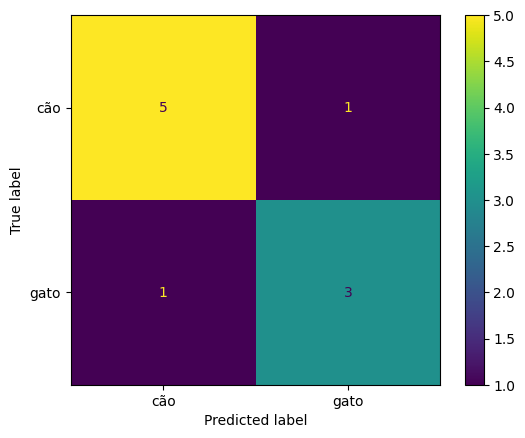

In [3]:
import matplotlib.pyplot as plt 

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['cão', 'gato'])
cm_display.plot()
plt.show()



**Exemplo:** Métricas aplicadas à classificação da base de dados Íris:

* Importação de bibliotecas, leitura do *DataSet* e divisão dos dados:

In [4]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=20
)

* Treino do modelo com *Decision Tree*:

In [5]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

* Acurácia:

In [6]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


* Precisão e *Recall*:

In [7]:
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))

Precision: 0.9487179487179488
Recall: 0.9393939393939394


* F1 *Score*:

In [8]:
print("F1 score:", f1_score(y_test, y_pred, average=None))

F1 score: [1.         0.91666667 0.9       ]


Estes são os $\text{Scores}\; F_1$ das classes 0,1 e 2. A média resulta em $F_1=0.938$.

In [9]:
print("F1 score:", f1_score(y_test, y_pred, average='macro'))

F1 score: 0.9388888888888888


* Matriz de Confusão:

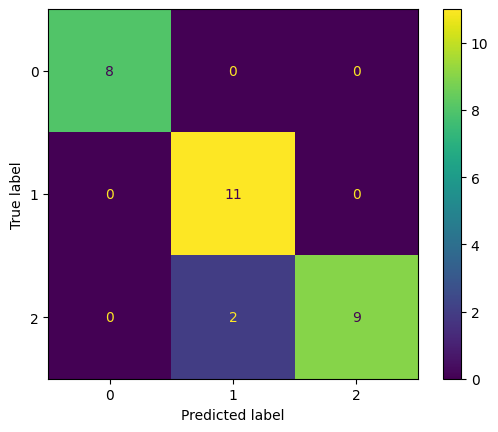

In [10]:
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[0, 1, 2])
cm_display.plot()
plt.show()

**Exercício:** Com base na matriz de confusão acima, calcule:
* Acurácia
* Precisão (Calcule a precisão para cada classe, a média aritmética das 3 classes e compare com o resultado do `sklearn`)
* Recal, usando o mesmo método acima
* Finalmente, calcule o F1 *Score* como a média aritmética dos F1 de cada classe.

### Métricas para Classificação

Em um problema de regressão as saídas não são classes discretas, mas algum valor numérico contínuo. Algumas métricas utilizadas são:
* Erro Absoluto médio (*Mean Absolute Error*)
  $$ MAE=\frac{1}{N}\sum_{i=1}^{N}\left|y_i-\hat{y}_i\right|$$
* Erro Médio Quadrático (*Mean Squared Error*)
   $$ MAE=\frac{1}{N}\sum_{i=1}^{N}\left(y_i-\hat{y}_i\right)^2$$
* $R^2$ - Coeficiente de determinação
  $$R^2=1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y}_i)^2}$$
